In [1]:
import sys
import os
sys.path.append('/home/apassi1/deepbottleneck')
from calc_encoding import load_encoding_results
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/apassi1/.conda/envs/backprop_pca/lib/python3

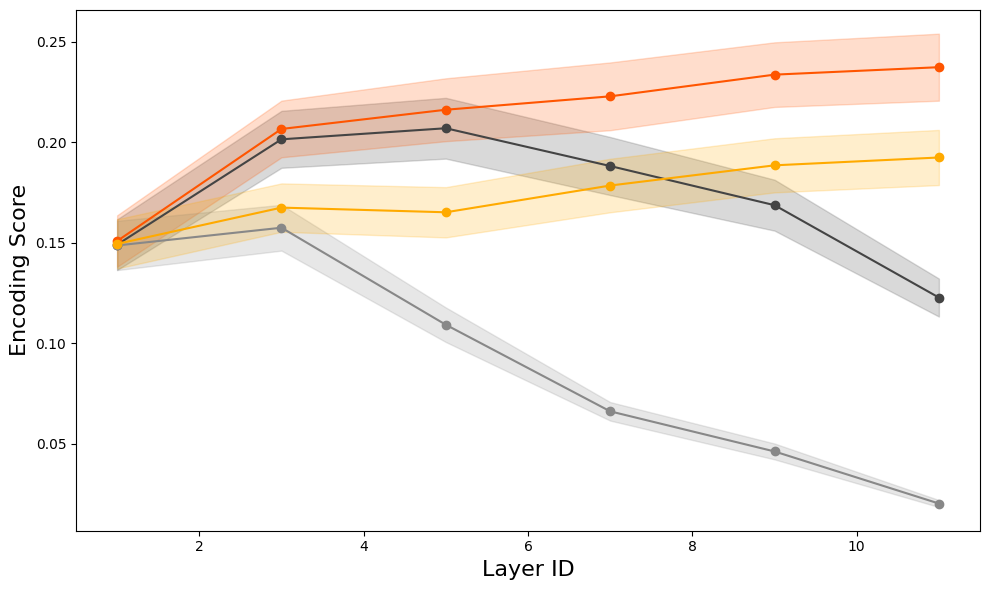

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import colorsys

# --- Load main models ---
encoding_label = 'new_imagenet-1k'
df = load_encoding_results(encoding_label=encoding_label)
df['model_epoch_label'] = df['model_label'] + '_epoch' + df['ckpt_epoch'].astype(str)

# --- Aggregate all ---
agg = (
    df.groupby(['layerid', 'model_epoch_label'])['encoding_score']
      .agg(['mean', 'sem'])
      .reset_index()
)

# --- Colors ---
classification_palette = sns.color_palette("autumn", 2)
pca_color = classification_palette[0]          # autumn yellow (Hybrid-1K Trained)
rand_color = classification_palette[1]         # autumn red (Rand Trained)
hybrid_untrained_color = '#444444'             # dark gray (Hybrid-1K Untrained)

def lighten_color(color, amount=0.6):
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mcolors.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

color_dict = {
    'new_imagenet-1k_rand_epoch0': '#888888',                # light gray (Rand Untrained)
    'new_imagenet-1k_rand_epoch2400': rand_color,            # autumn red (Rand Trained)
    'new_imagenet-1k_pca_epoch2400': pca_color,              # autumn yellow (Hybrid-1K Trained)
    'new_imagenet-1k_pca_epoch0': hybrid_untrained_color,    # dark gray (Hybrid-1K Untrained)
}

label_dict = {
    'new_imagenet-1k_rand_epoch0': 'Rand (Untrained)',
    'new_imagenet-1k_rand_epoch2400': 'Rand (Trained)',
    'new_imagenet-1k_pca_epoch0': 'Hybrid-1K (Untrained)',
    'new_imagenet-1k_pca_epoch2400': 'Hybrid-1K (Trained)',
}

plt.figure(figsize=(10, 6))
for model_epoch_label in agg['model_epoch_label'].unique():
    if model_epoch_label not in color_dict:
        continue
    model_data = agg[agg['model_epoch_label'] == model_epoch_label]
    plt.fill_between(
        model_data['layerid'],
        model_data['mean'] - model_data['sem'],
        model_data['mean'] + model_data['sem'],
        color=color_dict[model_epoch_label], alpha=0.2
    )
    plt.plot(
        model_data['layerid'],
        model_data['mean'],
        color=color_dict[model_epoch_label],
        label=label_dict[model_epoch_label],
        marker='o'
    )

plt.xlabel('Layer ID', fontsize=16)
plt.ylabel('Encoding Score', fontsize=16)
# plt.legend(title='Model/Epoch', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()

In [3]:
# import matplotlib.pyplot as plt

# plot_labels = ['new_imagenet-1k_rand_epoch0']
# color_dict = {'new_imagenet-1k_rand_epoch0': '#888888'}
# label_dict = {'new_imagenet-1k_rand_epoch0': 'Rand (Untrained)'}

# plt.figure(figsize=(10, 6))
# for model_epoch_label in plot_labels:
#     model_data = agg_full[agg_full['model_epoch_label'] == model_epoch_label]
#     plt.fill_between(
#         model_data['layerid'],
#         model_data['mean'] - model_data['sem'],
#         model_data['mean'] + model_data['sem'],
#         color=color_dict[model_epoch_label], alpha=0.2
#     )
#     plt.plot(
#         model_data['layerid'],
#         model_data['mean'],
#         color=color_dict[model_epoch_label],
#         marker='o'
#     )

# plt.xlabel('Layer ID', fontsize=16)
# plt.ylabel('Encoding Score', fontsize=16)
# plt.ylim(0, 0.3)
# plt.grid(False)
# plt.tight_layout()
# plt.show()

In [4]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# classification_palette = sns.color_palette("autumn", 2)
# rand_color = classification_palette[1]

# plot_labels = ['new_imagenet-1k_rand_epoch0', 'new_imagenet-1k_rand_epoch2400']
# color_dict = {
#     'new_imagenet-1k_rand_epoch0': '#888888',      # grey
#     'new_imagenet-1k_rand_epoch2400': rand_color,  # autumn red
# }

# plt.figure(figsize=(10, 6))
# for model_epoch_label in plot_labels:
#     model_data = agg_full[agg_full['model_epoch_label'] == model_epoch_label]
#     plt.fill_between(
#         model_data['layerid'],
#         model_data['mean'] - model_data['sem'],
#         model_data['mean'] + model_data['sem'],
#         color=color_dict[model_epoch_label], alpha=0.2
#     )
#     plt.plot(
#         model_data['layerid'],
#         model_data['mean'],
#         color=color_dict[model_epoch_label],
#         marker='o'
#     )

# plt.xlabel('Layer ID', fontsize=16)
# plt.ylabel('Encoding Score', fontsize=16)
# plt.ylim(0, 0.3)
# plt.grid(False)
# plt.tight_layout()
# plt.show()

In [5]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# classification_palette = sns.color_palette("autumn", 2)
# pca_color = classification_palette[0]
# rand_color = classification_palette[1]

# plot_labels = [
#     'new_imagenet-1k_rand_epoch0',
#     'new_imagenet-1k_rand_epoch2400',
#     'new_imagenet-1k_pca_epoch2400'
# ]
# color_dict = {
#     'new_imagenet-1k_rand_epoch0': '#888888',      # grey
#     'new_imagenet-1k_rand_epoch2400': rand_color,  # autumn red
#     'new_imagenet-1k_pca_epoch2400': pca_color,    # autumn yellow
# }

# plt.figure(figsize=(10, 6))
# for model_epoch_label in plot_labels:
#     model_data = agg_full[agg_full['model_epoch_label'] == model_epoch_label]
#     plt.fill_between(
#         model_data['layerid'],
#         model_data['mean'] - model_data['sem'],
#         model_data['mean'] + model_data['sem'],
#         color=color_dict[model_epoch_label], alpha=0.2
#     )
#     plt.plot(
#         model_data['layerid'],
#         model_data['mean'],
#         color=color_dict[model_epoch_label],
#         marker='o'
#     )

# plt.xlabel('Layer ID', fontsize=16)
# plt.ylabel('Encoding Score', fontsize=16)
# plt.ylim(0, 0.3)
# plt.grid(False)
# plt.tight_layout()
# plt.show()